In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [2]:
from typing import TypedDict, List, Annotated
from langgraph.graph.message import add_messages

class graph_schema(TypedDict):
    messages : Annotated[List,add_messages]


In [4]:
def welcome(state : graph_schema) -> graph_schema:
    curr_message = state['messages']

    response = model.invoke(curr_message).content

    state['message'] = response

    return state

In [5]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(graph_schema)

graph.add_node("welcome",welcome)

graph.add_edge(START,"welcome")
graph.add_edge("welcome",END)

## **Compile with checkpoint**

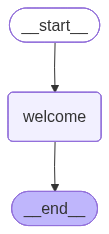

In [8]:
from IPython.display import Image,display
from langgraph.checkpoint.memory import InMemorySaver

checkpoint = InMemorySaver()

final_graph = graph.compile(checkpointer=checkpoint)

Image(final_graph.get_graph().draw_mermaid_png())

In [ ]:
final_graph.invoke(
    {"messages":"My name is Ansh"},
    {'configurable':{'thread_id':'ansh'}}
)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 17.596631271s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerM